In [137]:
import numpy as np

L = 6
B = 5
P = 278
Mx = 278
My = 250
ex = My / P
ey = -Mx / P
Xe = abs(ex)
Ye = abs(ey)
Ix = (L * B**3) / 12
Iy = (B * L**3) / 12
step = 0.002

print(f"Xe = {Xe:.6f}")
print(f"Ye = {Ye:.6f}")
print(f"Ix = {Ix}")
print(f"Iy = {Iy}")

# Initial pressures (Table A15:D18)
At_A = P/(B*L) - P*Ye/Ix * B/2 - P*Xe/Iy * L/2
At_B = P/(B*L) + P*Ye/Ix * B/2 - P*Xe/Iy * L/2
At_C = P/(B*L) + P*Ye/Ix * B/2 + P*Xe/Iy * L/2
At_D = P/(B*L) - P*Ye/Ix * B/2 + P*Xe/Iy * L/2

print(f"\nAt A = {At_A:.6f}")
print(f"At B = {At_B:.6f}")
print(f"At C = {At_C:.6f}")
print(f"At D = {At_D:.6f}")

# Determine Case
if At_A < 0 and At_B < 0:
    case = 2
elif At_A < 0 and At_D < 0:
    case = 3
elif At_A < 0:
    case = 4
elif At_A < 0 and At_B < 0 and At_C < 0:
    case = 5
else:
    case = 1

print(f"\nCase = {case}")

# Edge table - using ABS(P1/P2) as in Excel
# AB edge
length_AB = B
p1_AB = At_A
p2_AB = At_B
ratio_AB = abs(p1_AB / p2_AB)
dist_AB = length_AB * ratio_AB / (1 + ratio_AB)

# BC edge
length_BC = L
p1_BC = At_B
p2_BC = At_C
ratio_BC = abs(p1_BC / p2_BC)
R_BC = length_BC * ratio_BC / (1 + ratio_BC)

# AD edge
length_AD = L
p1_AD = At_A
p2_AD = At_D
ratio_AD = abs(p1_AD / p2_AD)
dist_AD = length_AD * ratio_AD / (1 + ratio_AD)

# DC edge
length_DC = B
p1_DC = At_D
p2_DC = At_C
ratio_DC = abs(p1_DC / p2_DC)
R_DC = length_DC * ratio_DC / (1 + ratio_DC)

print(f"\nEdge Table:")
print(f"  AB: ratio={ratio_AB:.6f}, R={dist_AB:.6f}")
print(f"  BC: ratio={ratio_BC:.6f}, R={R_BC:.6f}")
print(f"  AD: ratio={ratio_AD:.6f}, R={dist_AD:.6f}")
print(f"  DC: ratio={ratio_DC:.6f}, R={R_DC:.6f}")

# Trial Neutral Axis - For Case 4, use AB and AD
trial_AB = dist_AB
trial_AD = dist_AD

print(f"\nTrial Neutral Axis:")
print(f"  AB @ {trial_AB:.6f}")
print(f"  AD @ {trial_AD:.6f}")

# Edge coordinates for Case 4
# edge1 (AB): x=0, y=trial_AB
# edge2 (AD): x=trial_AD, y=0
x1 = 0
y1 = trial_AB
x2 = trial_AD
y2 = 0

print(f"\nEdge coordinates:")
print(f"  edge1: ({x1}, {y1})")
print(f"  edge2: ({x2}, {y2})")

# Neutral axis line equation: y = m*x + c
m = (y2 - y1) / (x2 - x1)
c = y1 - m * x1

print(f"\nNeutral axis: y = {m:.6f}x + {c:.6f}")

# For A and For C
For_A = (B - c) / m
For_C = m * L + c

print(f"For A = {For_A:.6f}")
print(f"For C = {For_C:.6f}")

# Final A and C
A_init = L - For_A
C_init = B - For_C

print(f"\nA = {A_init:.6f} m")
print(f"C = {C_init:.6f} m")

Xe = 0.899281
Ye = 1.000000
Ix = 62.5
Iy = 90.0

At A = -10.186667
At B = 12.053333
At C = 28.720000
At D = 6.480000

Case = 4

Edge Table:
  AB: ratio=0.845133, R=2.290168
  BC: ratio=0.419684, R=1.773708
  AD: ratio=1.572016, R=3.667200
  DC: ratio=0.225627, R=0.920455

Trial Neutral Axis:
  AB @ 2.290168
  AD @ 3.667200

Edge coordinates:
  edge1: (0, 2.2901678657074336)
  edge2: (3.6672000000000002, 0)

Neutral axis: y = -0.624500x + 2.290168
For A = -4.339200
For C = -1.456835

A = 10.339200 m
C = 6.456835 m


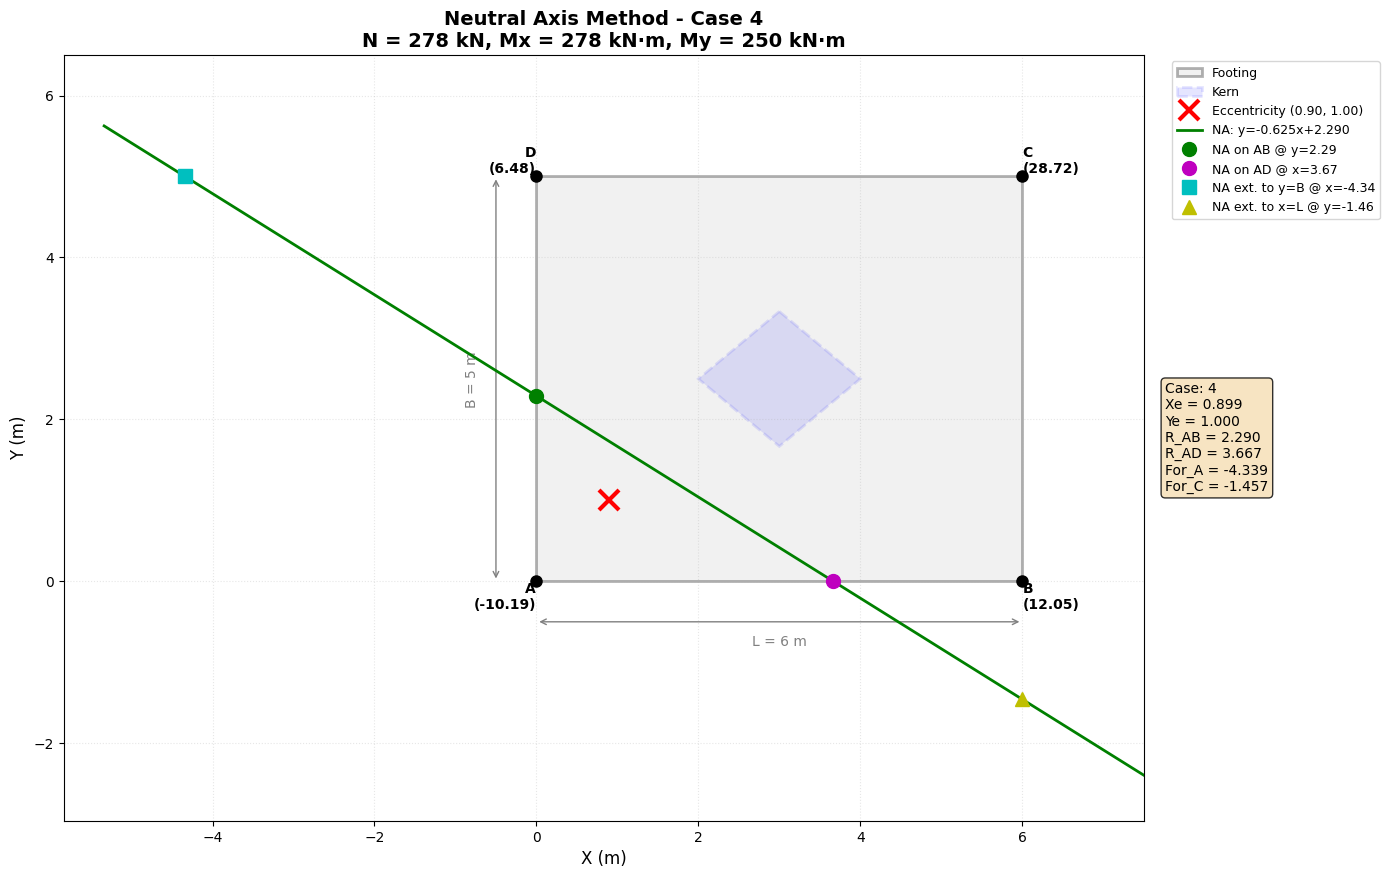

In [138]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Plot footing
footing = Rectangle((0, 0), L, B, linewidth=2, edgecolor='black', facecolor='lightgray', alpha=0.3, label='Footing')
ax.add_patch(footing)

# Corner labels with pressures
corners = {'A\n({:.2f})'.format(At_A): (0, 0), 'B\n({:.2f})'.format(At_B): (L, 0), 
           'C\n({:.2f})'.format(At_C): (L, B), 'D\n({:.2f})'.format(At_D): (0, B)}
for label, (x, y) in corners.items():
    ax.plot(x, y, 'ko', markersize=8)
    ha = 'right' if 'A' in label or 'D' in label else 'left'
    va = 'top' if 'A' in label or 'B' in label else 'bottom'
    x_off = -0.3 if ha == 'right' else 0.3
    y_off = -0.3 if va == 'top' else 0.3
    ax.annotate(label, (x, y), xytext=(x_off, y_off), textcoords='offset points', 
                fontsize=10, ha=ha, va=va, fontweight='bold')

# Plot Kern (diamond shape - correct geometry)
kern = Polygon([(L/2, B/2 + B/6), (L/2 + L/6, B/2), (L/2, B/2 - B/6), (L/2 - L/6, B/2)], 
               linewidth=2, edgecolor='blue', facecolor='blue', alpha=0.1, 
               linestyle='--', label='Kern')
ax.add_patch(kern)

# Plot eccentricity point
ax.plot(Xe, Ye, 'rx', markersize=15, markeredgewidth=3, label=f'Eccentricity ({Xe:.2f}, {Ye:.2f})', zorder=5)

# Plot Neutral Axis (extended range to show all intersections)
x_min = min(-2, For_A - 1)
x_max = max(L + 2, L + 1)
x_line = np.linspace(x_min, x_max, 100)
y_line = m * x_line + c
ax.plot(x_line, y_line, 'g-', linewidth=2, label=f'NA: y={m:.3f}x+{c:.3f}', zorder=4)

# Plot intersection points on footing edges
ax.plot(0, trial_AB, 'go', markersize=10, label=f'NA on AB @ y={trial_AB:.2f}', zorder=5)
ax.plot(trial_AD, 0, 'mo', markersize=10, label=f'NA on AD @ x={trial_AD:.2f}', zorder=5)

# Plot extended intersections with footing boundary lines
# For_A is where NA intersects y=B (top edge extended)
ax.plot(For_A, B, 'cs', markersize=10, label=f'NA ext. to y=B @ x={For_A:.2f}', zorder=5)
# For_C is where NA intersects x=L (right edge extended)
ax.plot(L, For_C, 'y^', markersize=10, label=f'NA ext. to x=L @ y={For_C:.2f}', zorder=5)

# Plot A_init and C_init distances if needed
# A_init = L - For_A (distance from right edge to NA intersection with top)
# C_init = B - For_C (distance from top edge to NA intersection with right)

# Dimensions
ax.annotate('', xy=(L, -0.5), xytext=(0, -0.5), arrowprops=dict(arrowstyle='<->', color='gray'))
ax.text(L/2, -0.8, f'L = {L} m', ha='center', fontsize=10, color='gray')
ax.annotate('', xy=(-0.5, B), xytext=(-0.5, 0), arrowprops=dict(arrowstyle='<->', color='gray'))
ax.text(-0.8, B/2, f'B = {B} m', ha='center', va='center', fontsize=10, color='gray', rotation=90)

# Auto-adjust limits to show all intersections including negative For_A
margin = 1.5
all_x = [0, L, For_A, trial_AD, Xe]
all_y = [0, B, For_C, trial_AB, Ye]
xlim_min = min(all_x) - margin
xlim_max = max(all_x) + margin
ylim_min = min(all_y) - margin
ylim_max = max(all_y) + margin

ax.set_xlim(xlim_min, xlim_max)
ax.set_ylim(ylim_min, ylim_max)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3, linestyle=':')
ax.set_xlabel('X (m)', fontsize=12)
ax.set_ylabel('Y (m)', fontsize=12)
ax.set_title(f'Neutral Axis Method - Case {case}\nN = {P} kN, Mx = {Mx} kN·m, My = {My} kN·m', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)

# Results box
textstr = '\n'.join([f'Case: {case}', f'Xe = {Xe:.3f}', f'Ye = {Ye:.3f}', 
                     f'R_AB = {trial_AB:.3f}', f'R_AD = {trial_AD:.3f}',
                     f'For_A = {For_A:.3f}', f'For_C = {For_C:.3f}'])
ax.text(1.02, 0.5, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()